## setup: imports and load model

In [1]:
import torch
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from utils.model_utils import get_encoder, get_decoder
from utils.data_utils.load_data import load_dataset, extract_target_properties
from utils.evaluate_utils.load_paths import load_paths
from utils.evaluate_utils.normalization import compute_normalized_mse
from utils.evaluate_utils import visualize_latent as latent
from utils.evaluate_utils import visualize_output as output
from utils.evaluate_utils.sampling import *
from utils.evaluate_utils.load_models import *
from sklearn.metrics import mean_squared_error

# === set seed and device ===
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# === model source toggle ===
THETA_MODEL = True           # set to False if using flow_checkpoints
TRIAL = 9
THETA_PATTERN = "100"        # only used if THETA_MODEL is True
USE_FLOW = False
FLOW_TYPE = "realnvp"        # only used if THETA_MODEL is False

# === load paths ===
paths = load_paths(
    TRIAL=TRIAL,
    THETA_MODEL=THETA_MODEL,
    THETA_PATTERN=THETA_PATTERN,
    USE_FLOW=USE_FLOW,
    FLOW_TYPE=FLOW_TYPE
)

trial_dir      = paths["trial_dir"]
DATA_PATH      = "data/test/dataset_test_x1000_augmented.csv"
config_path    = paths["config_path"]
encoder_path   = paths["encoder_path"]
decoder_path   = paths["decoder_path"]
P_mean_path    = paths["P_mean_path"]
P_std_path     = paths["P_std_path"]
S_mean_path    = paths["S_mean_path"]
S_std_path     = paths["S_std_path"]

✅ Loaded files from theta_100 for trial 9


## select a target & normalize

In [ ]:
# === load data ===
target_index = 4008
P_all, S_all, C_all = load_dataset(DATA_PATH)

P_true = P_all[target_index].unsqueeze(0).to(device)
S_true = S_all[target_index].cpu().numpy()
C_true = C_all[target_index]

print(f"✅ Set (Sᵢ, Pᵢ) index as i = {target_index}")
print(f"       - S_true: {S_true}")
print(f"       - P_true: {P_true}")
print(f"✅ S_true: {np.array2string(S_true, formatter={'float_kind':lambda x: f'{x:.5f}'})}")

# === compute C_fNN_true by evaluating S_true through the surrogate model ===
from re import S
from utils.data_utils.load_data import extract_target_properties
fNN = load_fNN_model() 
S_true_tf = np.expand_dims(S_true, axis=(0, 1))  # shape (1, 1, 4)
C_fNN_true = fNN(S_true_tf).numpy().reshape(1, 3, 3, 3, 3)[0]  # shape (3,3,3,3)

print("✅ C_fNN_true computed using Max's surrogate model")

# === load normalization constants ===
P_mean = np.load(P_mean_path)
P_std = np.load(P_std_path)
S_mean = np.load(S_mean_path)
S_std  = np.load(S_std_path)
S_std = np.where(S_std < 1e-8, 1.0, S_std) # prevent divide-by-zero

print(f"✅ Loaded S and P normalization constants:")
print(f"       - P_mean: {P_mean_path}")
print(f"       - P_std: {P_std_path}")
print(f"       - S_mean: {S_mean_path}")
print(f"       - S_std: {S_std_path}")

✅ Set (Sᵢ, Pᵢ) index as i = 4008
       - S_true: [20.167044   0.         0.         0.5501979]
       - P_true: tensor([[0.0601, 0.0431, 0.0420, 0.4940, 0.1471, 0.5062, 0.0321, 0.0322, 0.1760]])
✅ S_true: [20.16704 0.00000 0.00000 0.55020]


✅ Loaded Max's forward model
✅ C_fNN_true computed using Max's surrogate model
✅ Loaded S and P normalization constants:
       - P_mean: data/partition_by_theta/P_mean_theta_100.npy
       - P_std: data/partition_by_theta/P_std_theta_100.npy
       - S_mean: data/partition_by_theta/S_mean_theta_100.npy
       - S_std: data/partition_by_theta/S_std_theta_100.npy


## load models (fNN, config, encoder, decoder)

In [4]:
# === load models ===
fNN = load_fNN_model() 
config_dict = load_config(config_path)
decoder = load_decoder(config_dict, decoder_path, flow_type=FLOW_TYPE, trial=TRIAL, device=device)
encoder = load_encoder(config_dict, encoder_path, trial=TRIAL, device=device)

# === print config summary ===
print(f"✅ Config for trial {TRIAL}")
for k, v in config_dict.items():
    print(f"   - {k}: {v}")

# === optionally unpack config values for later ===
S_DIM = config_dict["S_DIM"]
P_DIM = config_dict["P_DIM"]
LATENT_DIM = config_dict["LATENT_DIM"]

✅ Loaded Max's forward model
✅ Loaded decoder from trial 9
✅ Loaded encoder from trial 9
✅ Config for trial 9
   - S_DIM: 4
   - P_DIM: 9
   - LATENT_DIM: 4
   - ENCODER_HIDDEN_DIMS: [128, 64, 32]
   - DECODER_HIDDEN_DIMS: [128, 64, 32]
   - BATCH_SIZE: 64
   - LEARNING_RATE: 0.0005
   - NUM_EPOCHS: 150
   - BETA: 0.3
   - NUM_FLOWS: 4
   - DROPOUT_PROB: 0.0
   - USE_FLOW_DECODER: False
   - USE_ATTENTION_ENCODER: True
   - USE_ATTENTION_DECODER: True
   - THETA_PATTERN: 100
   - TRIAL: 9


/Users/ellielin/Desktop/dresden/inverse_design_spinodoids/spinodoid_cvae_dev/utils/evaluate_utils/load_models.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  decoder.lo

## sample S-hat predictions and enforce domain

In [5]:
# === sample from decoder ===
P_true_norm = (P_true.cpu().numpy() - P_mean) / (P_std + 1e-8)
P_true_norm = torch.tensor(P_true_norm, dtype=torch.float32).to(device) # since we normalized during training

S_hats_norm = get_S_hats(decoder, P_true_norm, LATENT_DIM, num_samples=1000, seed=SEED, device=device)

# === choose bandwidth and extract peaks (still in normalized space) ===
S_hat_peaks_norm, bw_used = extract_peaks_with_bandwidth(
    S_hats_norm,
    use_auto_bandwidth=True,    # toggle for auto
    manual_bw=0.6,
    target_range=(1, 10)
)

# === sort peaks by empirical probability ===
S_hat_peaks_norm, probs, counts = sort_and_select_peaks_by_probability(
    S_hats_norm, 
    S_hat_peaks_norm, 
    bw_used, 
    prob_threshold=0.10
)

# === DENORMALIZE S ====
S_hat_peaks_unnorm = S_hat_peaks_norm * S_std + S_mean
print("✅ Denormalized S_hat_peaks")


✅ [Auto] Selected bandwidth: 0.10 → Found 1 peak(s)

✅ Sorted empirical probabilities for each peak (≥ 0.10):
  Peak 0: 1000 samples (1.000)
✅ Denormalized S_hat_peaks


In [6]:
# === enforce theta domain and filter S candidates ===
from utils.evaluate_utils.structure_constraints import *
S_hat_peaks_unnorm = enforce_theta_domain(S_hat_peaks_unnorm)
S_hat_peaks_unnorm = filter_S_candidates(S_hat_peaks_unnorm)
print(f"✅ Filtered peaks count: {len(S_hat_peaks_unnorm)}")

✅ Filtered peaks count: 1


## encoder latent space diagnostics (optional)

/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Cluster-color mapping:
    - Cluster 0: deepskyblue
    - Cluster 1: lightcoral
    - Cluster 2: lightgreen


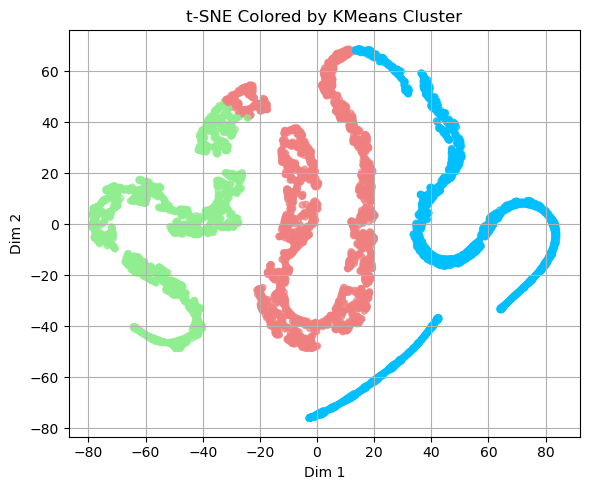


✅ Extracting region:
  → Target Cluster: 1
  → X bounds: 50 to 100
  → Y bounds: 0 to 50

✅ Showing up to 5 region examples:


In [7]:
# === get latent representations ===
Z_mu = latent.compute_latent_representations(encoder, P_all, S_all, device=device)
Z_2D = latent.reduce_latent_dim(Z_mu, method='tsne', seed=SEED)

# === cluster latents ===
cluster_labels = latent.cluster_latents(Z_mu, n_clusters=3, seed=SEED)
latent.plot_latents(Z_2D, cluster_labels)

# === extract cluster region ===
region_indices = latent.extract_cluster_region(Z_2D, cluster_labels, target_cluster=1, x_bounds=(50, 100), y_bounds=(0, 50))
latent.print_region_examples(region_indices, S_all, P_all, max_examples=5)

## visualize decoder output space

,Ŝ,S_true,ΔS
0,"[20.32631, 0.00000, 0.00000, 0.55363]","[20.16704, 0.00000, 0.00000, 0.55020]","[0.15926, 0.00000, 0.00000, 0.00343]"


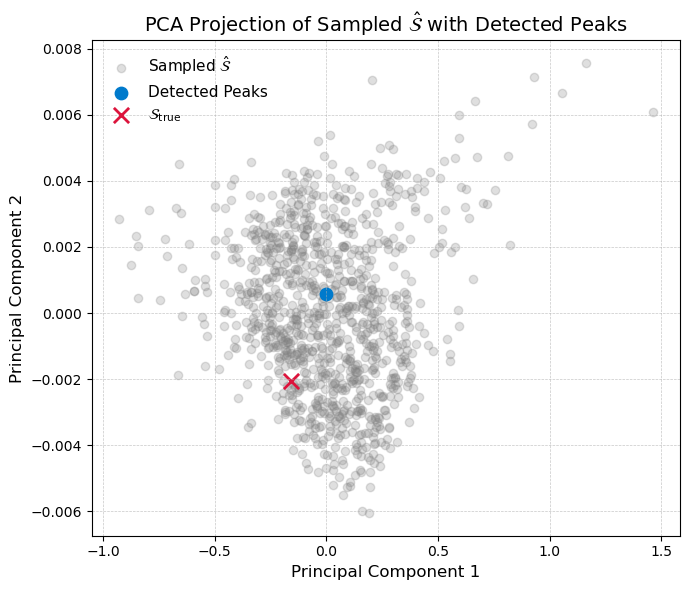

In [8]:
df_candidates = make_candidate_table(S_hat_peaks_unnorm, S_true)
output.plot_S_hat_space(S_hats_norm * S_std + S_mean, S_true, S_hat_peaks_unnorm)

## plot P vs P-hat (from both CVAE and fNN)


✅ Mean MSE across all peaks (unnormalized): 0.00001



Peak,||P-hat - P||,MSE
0,0.0112,0.000014


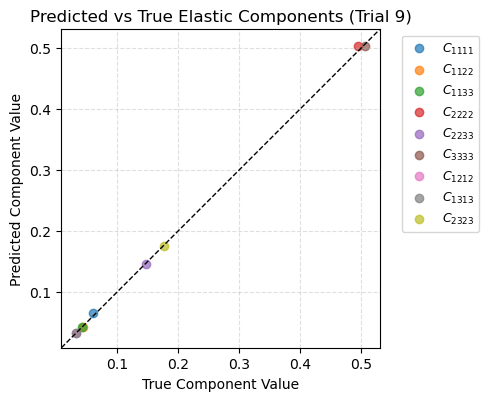

In [9]:
# === evaluate peaks and get metrics ===
P_true = np.array(P_true).flatten()  # flatten for plotting
P_preds, errors, mses, df_peaks, C_preds = output.evaluate_peaks(S_hat_peaks_unnorm, P_true, fNN)

# === compute MSE manually on unnormalized values ===
mean_mse = np.mean(mses)
# output.plot_all_P_preds_vs_true(P_preds, P_true)
# output.plot_all_P_preds_vs_true_with_fNN_uncertainty(P_preds, P_true_unnorm, S_true, fNN, P_std, P_mean)
# output.plot_per_component_bars(P_preds, P_true, P_mean, P_std)
output.plot_pred_vs_true_scatter(P_true, P_preds, trial=TRIAL)

In [10]:
from utils.evaluate_utils.error import compute_tensor_error

# === error computation ===
error_fNN = compute_tensor_error(C_true, C_fNN_true)
status_fNN = "✅" if error_fNN < 0.08 else "❌"
print("Percent error: PASS if error < 8%")
print(f"{status_fNN} C_fNN_true: {error_fNN:.4%} — {'PASS' if error_fNN < 0.08 else 'FAIL'}")

for i, C_hat in enumerate(C_preds):
    err = compute_tensor_error(C_true, C_hat)
    status = "✅" if err < 0.08 else "❌"
    print(f"{status} C_hat_{i}: {err:.4%} — {'PASS' if err < 0.08 else 'FAIL'}")

Percent error: PASS if error < 8%
✅ C_fNN_true: 2.3614% — PASS
✅ C_hat_0: 2.3520% — PASS


## comprehensive aggregate stats

In [11]:
output.evaluate_mse_and_pass_count_per_target_pair(
    decoder, P_all, S_all, C_all, LATENT_DIM, fNN,
    P_mean, P_std, S_mean, S_std,
    bw="auto", N=20, threshold=0.08, seed=42, device=None
)

Evaluating target pairs: 100%|██████████| 20/20 [00:05<00:00,  3.35pair/s]


✅ avg mse: 0.00008
✅ avg passing candidates: 0.50
✅ avg pass rate: 90.9090909090909% 
✅ avg interesting candidates: 0.5


index,S_true,avg_mse,num_candidates,num_pass,pass_rate,num_interesting
0,"[34.4427, 87.3751, 0.0, 0.5033]",0.00002,1,1,100.0,1
1,"[87.3751, 0.0, 34.4427, 0.5033]",0.00001,1,1,100.0,1
2,"[0.0, 34.4427, 87.3751, 0.5033]",NaN,0,0,NaN,0
3,"[0.0, 87.3751, 34.4427, 0.5033]",NaN,0,0,NaN,0
4,"[34.4427, 0.0, 87.3751, 0.5033]",NaN,0,0,NaN,0
5,"[87.3751, 34.4427, 0.0, 0.5033]",0.00001,1,1,100.0,1
6,"[71.2844, 87.0958, 0.0, 0.6597]",NaN,0,0,NaN,0
7,"[87.0958, 0.0, 71.2844, 0.6597]",0.00002,1,1,100.0,1
8,"[0.0, 71.2844, 87.0958, 0.6597]",NaN,0,0,NaN,0
9,"[0.0, 87.0958, 71.2844, 0.6597]",0.00005,1,1,100.0,1


(8.36363631771581e-05, 0.5, 90.9090909090909, 0.5)

## young's modulus visualization

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from utils.evaluate_utils.plot_elastic_surface import plot_elastic_surface

# === pretty formatting helper ===
def format_array(arr, precision=5):
    return "[" + ", ".join(f"{x:.{precision}f}" for x in arr) + "]"

# === prepare all tensors and titles ===
all_Cs = [C_true, C_fNN_true] + list(C_preds)
all_labels = (
    [f"C_true  (S = {format_array(S_true)})",
     f"C_fNN_true  (S = {format_array(S_true)})"]
    + [f"C_hat_{i+1}  (Ŝ = {format_array(S_hat_peaks_unnorm[i])})" for i in range(len(C_preds))]
)

# === plot all surfaces ===
print(f"\n✅ Plotting Young's Modulus Surfaces ({len(all_Cs)} total)...")

for i, (C, label) in enumerate(zip(all_Cs, all_labels)):
    print(f"\n✅ {label}")
    plot_elastic_surface(C)